# 30. 첫 반응군 리뷰 텍스트 탐색 분석

**분석 목적:** 첫 반응군(Steam 총 리뷰 10~49개) 층화 샘플의 리뷰 텍스트에서 두 가지 축을 탐색한다.

1. **플레이타임 구간별 리뷰 패턴** — 몇 시간 플레이 후 리뷰가 작성되는지, 구간별 텍스트가 어떻게 달라지는지
2. **긍정/부정 리뷰 키워드 대조** — `voted_up` 기준으로 두 그룹을 나눠 차별 키워드 및 불만 카테고리 확인

**데이터:**
- `steam_indie_first_response_sample.csv` — 31번 노트북에서 생성한 첫 반응군 층화 샘플 200개 게임
- `steam_indie_first_response_reviews.csv` — 위 샘플 게임의 Steam 리뷰 수집본

**분석 대상:** 샘플 200개 중 리뷰 수집에 성공한 198개 게임, 그중 영어 리뷰가 존재하는 190개 게임의 영어 리뷰 2,465개를 분석한다.

**분석 방법:** TF-IDF 키워드 분석 + 규칙 기반 불만 키워드 분류. LLM 분류 결과가 아니므로 원인 비율은 확정값이 아니라 텍스트 신호의 탐색 결과로 해석한다.

**PPT 연결:** Slide 33 또는 Slide 36 — 첫 반응군 리뷰 텍스트 기반 초기 유저 반응 및 출시 후 개선 포인트 탐색

## 0. 환경 설정 및 데이터 로드

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# 한글 폰트 설정 (macOS: AppleGothic, Linux/Windows: NanumGothic 등으로 교체)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR     = Path('../../../data/preprocessed')
REVIEWS_FILE = DATA_DIR / 'steam_indie_first_response_reviews.csv'
SAMPLE_FILE  = DATA_DIR / 'steam_indie_first_response_sample.csv'

NAVY      = '#2D3E71'
CREAM     = '#FAF9F6'
POS_COLOR = '#4C72B0'
NEG_COLOR = '#C44E52'

PLAYTIME_BINS   = [0, 1, 3, 10, float('inf')]
PLAYTIME_LABELS = ['< 1h', '1 ~ 3h', '3 ~ 10h', '10h +']
PLAYTIME_COLORS = ['#8EB4D4', '#5A8FBF', '#2D6FA4', NAVY]

In [19]:
rv = pd.read_csv(REVIEWS_FILE)
sample = pd.read_csv(SAMPLE_FILE)

# 영어 리뷰만 사용 (텍스트 분석)
df_en = rv[rv['language'] == 'english'].copy()
df_en = df_en.dropna(subset=['review'])
df_en['review'] = df_en['review'].astype(str)

print(f'층화 샘플 게임 수  : {sample["appid"].nunique():,}개')
print(f'리뷰 수집 게임 수  : {rv["appid"].nunique():,}개')
print(f'영어 리뷰 게임 수  : {df_en["appid"].nunique():,}개')
print(f'전체 리뷰 수       : {len(rv):,}개')
print(f'영어 리뷰 수       : {len(df_en):,}개')
print(f'플레이타임 중앙값  : {df_en["playtime_at_review_hours"].median():.2f}h')
print(f'긍정 리뷰 비율     : {df_en["voted_up"].mean():.1%}')

층화 샘플 게임 수  : 200개
리뷰 수집 게임 수  : 198개
영어 리뷰 게임 수  : 190개
전체 리뷰 수       : 4,677개
영어 리뷰 수       : 2,465개
플레이타임 중앙값  : 1.48h
긍정 리뷰 비율     : 82.5%


## 1. 텍스트 전처리 함수

In [20]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 게임 리뷰에서 의미 없는 단어 추가 제거
CUSTOM_STOPWORDS = {
    'game', 'play', 'playing', 'played', 'games', 'like',
    'get', 'one', 'time', 'really', 'also', 'would', 'make',
    'much', 'lot', 'little', 'even', 'still', 'well', 'way',
    'good', 'great', 'bad', 'nice', 'best', 'dont', 'doesnt',
    'cant', 'ive', 'im', 'its', 'it', 'the', 'a', 'an',
    'this', 'that', 'i', 'you', 'we', 'they', 'he', 'she',
    # TF-IDF 차트의 해석력을 낮추는 일반 표현
    'feel', 'could', 'thing', 'got', 'see', 'bit', 'right',
    'player', 'work', 'need', 'first', 'use', 'something',
    'everything', 'anything', 'review', 'unfortunately',
}
stop_words |= CUSTOM_STOPWORDS


def preprocess(text: str) -> str:
    tokens = word_tokenize(text.lower())
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in stop_words and len(t) > 2
    ]
    return ' '.join(tokens)


df_en['clean_review'] = df_en['review'].apply(preprocess)
print('전처리 완료')
print('예시:', df_en['clean_review'].iloc[0][:120])

전처리 완료
예시: puzzle disguise puzzle carefully navigate level gain golden toad collectible level optional combat opponent portal gathe


## 2. 플레이타임 구간별 분석

### 2-1. 플레이타임 분포 개요

In [21]:
df_en['playtime_bin'] = pd.cut(
    df_en['playtime_at_review_hours'],
    bins=PLAYTIME_BINS,
    labels=PLAYTIME_LABELS,
    right=False,
)

pt_summary = (
    df_en.groupby('playtime_bin', observed=True)
    .agg(
        리뷰수=('review', 'count'),
        긍정률=('voted_up', 'mean'),
        플레이타임_중앙값=('playtime_at_review_hours', 'median'),
        리뷰길이_중앙값=('review', lambda x: x.str.split().str.len().median()),
    )
    .reset_index()
)
pt_summary['비율(%)'] = (pt_summary['리뷰수'] / pt_summary['리뷰수'].sum() * 100).round(1)
pt_summary['긍정률'] = (pt_summary['긍정률'] * 100).round(1)

display(pt_summary)

,playtime_bin,리뷰수,긍정률,플레이타임_중앙값,리뷰길이_중앙값,비율(%)
0,< 1h,950,72.1,0.4833,33.0,38.5
1,1 ~ 3h,770,89.5,1.7000,41.0,31.2
2,3 ~ 10h,475,88.2,4.9167,49.0,19.3
3,10h +,270,89.3,17.8500,60.0,11.0


In [22]:
fig = px.bar(
    pt_summary,
    x='playtime_bin',
    y='비율(%)',
    color='playtime_bin',
    color_discrete_sequence=PLAYTIME_COLORS,
    text='비율(%)',
    title='유반응군 영어 리뷰 — 플레이타임 구간별 비율',
    labels={'playtime_bin': '플레이타임 구간', '비율(%)': '리뷰 비율 (%)'},
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False, height=420, plot_bgcolor=CREAM, paper_bgcolor=CREAM)
fig.show()

**해석:**
- 첫 반응군 영어 리뷰의 플레이타임 중앙값과 리뷰 작성 시점 분포를 확인한다.
- 리뷰의 상당수가 3시간 이내에 작성된다면, 초기 플레이 경험이 리뷰 형성에 큰 비중을 차지할 가능성이 있다.
- 이는 유반응군에서 고반응군으로 성장하기 위해 온보딩, 초반 루프, 첫 인상 품질을 우선 점검해야 한다는 운영 시사점으로 연결된다.
- 단, 플레이타임과 리뷰 감성의 관계는 관찰된 상관 패턴이며, 초반 경험이 리뷰를 결정한다고 인과적으로 단정하지 않는다.

### 2-2. 플레이타임 구간별 TF-IDF 키워드

In [23]:
TOP_N = 10

pt_keywords = {}

for label in PLAYTIME_LABELS:
    docs = df_en[df_en['playtime_bin'] == label]['clean_review'].tolist()
    if len(docs) < 5:
        continue
    tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)
    tfidf.fit(docs)
    scores = tfidf.transform(docs).toarray().mean(axis=0)
    vocab  = tfidf.get_feature_names_out()
    top_idx = scores.argsort()[::-1][:TOP_N]
    pt_keywords[label] = [(vocab[i], round(scores[i], 4)) for i in top_idx]

for label, kws in pt_keywords.items():
    print(f'\n=== {label} ===')
    for word, score in kws:
        print(f'  {word:<25} {score:.4f}')


=== < 1h ===
  fun                       0.0419
  love                      0.0234
  gameplay                  0.0233
  level                     0.0230
  short                     0.0227
  puzzle                    0.0191
  control                   0.0183
  art                       0.0169
  price                     0.0168
  recommend                 0.0166

=== 1 ~ 3h ===
  fun                       0.0589
  level                     0.0299
  love                      0.0285
  story                     0.0284
  puzzle                    0.0281
  short                     0.0257
  recommend                 0.0249
  cute                      0.0228
  gameplay                  0.0220
  horror                    0.0188

=== 3 ~ 10h ===
  fun                       0.0736
  level                     0.0342
  love                      0.0316
  story                     0.0291
  puzzle                    0.0272
  recommend                 0.0247
  cute                      0.0216
  hour  

In [24]:
from plotly.subplots import make_subplots

valid_labels = [l for l in PLAYTIME_LABELS if l in pt_keywords]
n_cols = 2
n_rows = (len(valid_labels) + 1) // 2

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=[f'{l} (n={len(df_en[df_en["playtime_bin"]==l])}개)' for l in valid_labels],
)

for idx, label in enumerate(valid_labels):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    kws = pt_keywords[label]
    words  = [k[0] for k in kws][::-1]
    scores = [k[1] for k in kws][::-1]
    fig.add_trace(
        go.Bar(
            x=scores, y=words,
            orientation='h',
            marker_color=PLAYTIME_COLORS[PLAYTIME_LABELS.index(label)],
            showlegend=False,
        ),
        row=row, col=col,
    )

fig.update_layout(
    title='플레이타임 구간별 TF-IDF 상위 키워드',
    height=500, plot_bgcolor=CREAM, paper_bgcolor=CREAM,
)
fig.show()

**해석:**
- 구간별 키워드가 어떻게 달라지는지 확인한다.
- 예상 패턴: **<1h 구간** → 조작감·첫 인상·짧은 경험 관련 단어 / **10h+ 구간** → 캐릭터·스토리·볼륨 등 누적 경험 단어
- 유반응군에서 리뷰의 다수가 짧은 플레이 이후 작성된다면, 인디 개발자는 첫 온보딩과 초반 루프 품질에 집중해야 한다는 전략 시사점이 도출된다.
- TF-IDF 키워드는 단어 빈도 기반 탐색 결과이므로, 원인 분류나 감성 판단의 확정 근거로 쓰지 않는다.

## 3. 긍정/부정 리뷰 키워드 대조

### 3-1. 그룹별 기본 현황

In [25]:
pos = df_en[df_en['voted_up'] == True].copy()
neg = df_en[df_en['voted_up'] == False].copy()

summary = pd.DataFrame({
    '그룹': ['긍정 (voted_up=True)', '부정 (voted_up=False)'],
    '리뷰 수': [len(pos), len(neg)],
    '비율(%)': [
        round(len(pos) / len(df_en) * 100, 1),
        round(len(neg) / len(df_en) * 100, 1),
    ],
    '리뷰 길이 중앙값(단어)': [
        pos['review'].str.split().str.len().median(),
        neg['review'].str.split().str.len().median(),
    ],
    '플레이타임 중앙값(h)': [
        pos['playtime_at_review_hours'].median().round(2),
        neg['playtime_at_review_hours'].median().round(2),
    ],
})
display(summary)

,그룹,리뷰 수,비율(%),리뷰 길이 중앙값(단어),플레이타임 중앙값(h)
0,긍정 (voted_up=True),2034,82.5,37.0,1.67
1,부정 (voted_up=False),431,17.5,66.0,0.72


### 3-2. 그룹별 TF-IDF 상위 키워드

In [26]:
def get_tfidf_top(docs, n=15):
    tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
    tfidf.fit(docs)
    scores = tfidf.transform(docs).toarray().mean(axis=0)
    vocab  = tfidf.get_feature_names_out()
    top_idx = scores.argsort()[::-1][:n]
    return pd.DataFrame({'keyword': vocab[top_idx], 'score': scores[top_idx].round(4)})


pos_kw = get_tfidf_top(pos['clean_review'].tolist())
neg_kw = get_tfidf_top(neg['clean_review'].tolist())

print('=== 긍정 리뷰 Top 15 ===')
display(pos_kw)
print('\n=== 부정 리뷰 Top 15 ===')
display(neg_kw)

=== 긍정 리뷰 Top 15 ===


,keyword,score
0,fun,0.0520
1,love,0.0257
2,level,0.0229
3,puzzle,0.0214
4,story,0.0213
5,short,0.0194
6,recommend,0.0194
7,cute,0.0186
8,gameplay,0.0174
9,pretty,0.0150



=== 부정 리뷰 Top 15 ===


,keyword,score
0,level,0.0246
1,gameplay,0.0209
2,control,0.0203
3,fun,0.0180
4,recommend,0.0180
5,boring,0.0177
6,feel,0.0168
7,enemy,0.0166
8,nothing,0.0160
9,buy,0.0155


In [27]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f'긍정 리뷰 TF-IDF Top 15 (n={len(pos)})',
        f'부정 리뷰 TF-IDF Top 15 (n={len(neg)})',
    ],
)

for col_idx, (kw_df, color, label) in enumerate([
    (pos_kw, POS_COLOR, '긍정'),
    (neg_kw, NEG_COLOR, '부정'),
], start=1):
    fig.add_trace(
        go.Bar(
            x=kw_df['score'][::-1],
            y=kw_df['keyword'][::-1],
            orientation='h',
            marker_color=color,
            name=label,
            showlegend=False,
        ),
        row=1, col=col_idx,
    )

fig.update_layout(
    title='긍정 vs 부정 리뷰 TF-IDF 키워드 비교',
    height=500, plot_bgcolor=CREAM, paper_bgcolor=CREAM,
)
fig.show()

### 3-3. 차별 키워드: 한쪽에서만 두드러지는 단어

In [28]:
# 두 그룹을 합쳐 공통 어휘를 기준으로 상대 비중 차이 계산
all_docs = pos['clean_review'].tolist() + neg['clean_review'].tolist()
labels_vec = ['pos'] * len(pos) + ['neg'] * len(neg)

tfidf_all = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=3)
tfidf_all.fit(all_docs)
vocab_all = tfidf_all.get_feature_names_out()

pos_scores_all = tfidf_all.transform(pos['clean_review'].tolist()).toarray().mean(axis=0)
neg_scores_all = tfidf_all.transform(neg['clean_review'].tolist()).toarray().mean(axis=0)

diff_df = pd.DataFrame({
    'keyword': vocab_all,
    'pos_score': pos_scores_all,
    'neg_score': neg_scores_all,
})
diff_df['diff'] = diff_df['pos_score'] - diff_df['neg_score']
diff_df = diff_df.sort_values('diff')

# 부정에서 두드러진 키워드 (diff 가장 낮음)
neg_dominant = diff_df.head(15).copy()
# 긍정에서 두드러진 키워드 (diff 가장 높음)
pos_dominant = diff_df.tail(15).copy()

print('=== 부정 리뷰에서 두드러진 키워드 (긍정 대비) ===')
display(neg_dominant[['keyword', 'neg_score', 'pos_score', 'diff']].round(4))

print('\n=== 긍정 리뷰에서 두드러진 키워드 (부정 대비) ===')
display(pos_dominant[['keyword', 'pos_score', 'neg_score', 'diff']].round(4))

=== 부정 리뷰에서 두드러진 키워드 (긍정 대비) ===


,keyword,neg_score,pos_score,diff
90,boring,0.0198,0.0008,-0.0190
587,nothing,0.0199,0.0039,-0.0160
177,control,0.0232,0.0091,-0.0141
316,feel,0.0198,0.0079,-0.0119
107,buy,0.0169,0.0056,-0.0114
934,unit,0.0130,0.0022,-0.0108
264,enemy,0.0180,0.0077,-0.0102
710,refund,0.0104,0.0007,-0.0097
466,key,0.0119,0.0023,-0.0096
150,clunky,0.0102,0.0008,-0.0095



=== 긍정 리뷰에서 두드러진 키워드 (부정 대비) ===


,keyword,pos_score,neg_score,diff
382,graphic,0.0138,0.0063,0.0075
621,perfect,0.0078,0.0001,0.0077
420,horror,0.0141,0.0062,0.0079
933,unique,0.0094,0.0014,0.0081
410,highly,0.0102,0.0014,0.0088
778,short,0.0199,0.0110,0.0089
786,simple,0.0125,0.0034,0.0090
842,story,0.0219,0.0127,0.0092
213,definitely,0.0126,0.0028,0.0098
124,challenge,0.0121,0.0020,0.0102


In [29]:
# 차별 키워드 시각화: 긍정 우세 ↔ 부정 우세
top_pos = diff_df.tail(12).copy()
top_neg = diff_df.head(12).copy()
diverge = pd.concat([top_neg, top_pos]).reset_index(drop=True)
diverge['color'] = diverge['diff'].apply(lambda x: POS_COLOR if x > 0 else NEG_COLOR)
diverge['label'] = diverge['diff'].apply(lambda x: '긍정 우세' if x > 0 else '부정 우세')

fig = px.bar(
    diverge,
    x='diff',
    y='keyword',
    orientation='h',
    color='label',
    color_discrete_map={'긍정 우세': POS_COLOR, '부정 우세': NEG_COLOR},
    title='긍정/부정 리뷰 차별 키워드 (TF-IDF 점수 차이)',
    labels={'diff': 'TF-IDF 점수 차이 (긍정 − 부정)', 'keyword': '키워드'},
)
fig.add_vline(x=0, line_dash='dash', line_color='gray')
fig.update_layout(
    height=520, plot_bgcolor=CREAM, paper_bgcolor=CREAM,
    yaxis=dict(categoryorder='total ascending'),
)
fig.show()

**해석:**
- 차별 키워드 차트에서 **왼쪽(부정 우세)** 에 등장하는 단어들은 첫 반응군 게임의 부정 리뷰에서 상대적으로 두드러진 텍스트 신호다.
- 이 단어들이 가격·콘텐츠 볼륨·버그·난이도 등 어느 카테고리에 집중되는지를 보면, 유반응에서 고반응으로 성장하지 못하는 병목 후보를 구체화할 수 있다.
- **오른쪽(긍정 우세)** 키워드는 첫 반응을 이끈 긍정 요소 후보로, 인디 개발자가 스토어 페이지·트레일러에서 강조할 포인트와 연결할 수 있다.
- 다만 TF-IDF 차이는 키워드 기반 탐색 결과이며, 특정 단어가 긍정/부정의 직접 원인임을 의미하지 않는다.

## 4. 부정 리뷰 불만 카테고리 분류

In [30]:
import re

# 규칙 기반으로 부정 리뷰를 불만 카테고리로 분류
# 단순 부분 문자열 매칭은 recommend 안의 end처럼 오탐이 생기므로 단어 경계 기반으로 탐지한다.
COMPLAINT_RULES = {
    '버그/기술적 문제': [
        r'\bbugs?\b', r'\bcrash(?:es|ed|ing)?\b', r'\bglitches?\b',
        r'\bbroken\b', r'\berrors?\b', r'\bissues?\b', r'\bproblems?\b',
        r'\bfreez(?:e|es|ing)\b', r'\blags?\b', r'\bperformance\b',
    ],
    '볼륨/분량 부족': [
        r'\btoo short\b', r'\bshort\b', r'\bcontent\b', r'\black(?:s|ing|ed)?\b',
        r'\bnot enough\b', r'\bempty\b', r'\blimited\b', r'\bhours?\b',
        r'\blength\b', r'\bfinish(?:ed|es|ing)?\b',
    ],
    '가격/가치 문제': [
        r'\bprices?\b', r'\bexpensive\b', r'\bworth\b', r'\bcheap\b',
        r'\bmoney\b', r'\boverpriced\b', r'\bvalue\b', r'\bcosts?\b',
        r'\bdollars?\b', r'\brefund(?:ed|s)?\b',
    ],
    '난이도/밸런스': [
        r'\bdifficult\b', r'\bhard\b', r'\beasy\b', r'\bbalanc(?:e|ed|ing)\b',
        r'\bunfair\b', r'\bfrustrat\w*\b', r'\bpunish\w*\b', r'\brng\b',
        r'\brandom\b', r'\bchalleng(?:e|es|ing)?\b',
    ],
    '반복성/지루함': [
        r'\brepeat\w*\b', r'\bboring\b', r'\bgrind\w*\b', r'\bmonoton\w*\b',
        r'\brepetitive\b', r'\bsame\b', r'\btedious\b', r'\bdull\b',
        r'\black variety\b',
    ],
    '조작/UI': [
        r'\bcontrols?\b', r'\bcontrollers?\b', r'\bkeyboard\b', r'\bmouse\b',
        r'\bui\b', r'\binterface\b', r'\bclunky\b', r'\bawkward\b',
        r'\bnavigat\w*\b',
    ],
}

COMPLAINT_PATTERNS = {
    cat: [re.compile(pattern, flags=re.IGNORECASE) for pattern in patterns]
    for cat, patterns in COMPLAINT_RULES.items()
}


def classify_complaint(text: str) -> list[str]:
    categories = [
        cat
        for cat, patterns in COMPLAINT_PATTERNS.items()
        if any(pattern.search(text) for pattern in patterns)
    ]
    return categories if categories else ['기타']


neg = neg.copy()
neg['categories'] = neg['review'].apply(classify_complaint)
neg['category_count'] = neg['categories'].apply(len)
neg_exploded = neg.explode('categories')

cat_counts = (
    neg_exploded['categories']
    .value_counts()
    .reset_index()
)
cat_counts.columns = ['카테고리', '언급 리뷰 수']
cat_counts['비율(%)'] = (cat_counts['언급 리뷰 수'] / len(neg) * 100).round(1)

multi_category_rate = (neg['category_count'] > 1).mean() * 100
other_only_rate = (neg['categories'].apply(lambda cats: cats == ['기타'])).mean() * 100

print(f'부정 리뷰 수: {len(neg):,}개')
print(f'복수 카테고리 분류 비율: {multi_category_rate:.1f}%')
print(f'기타 단독 분류 비율: {other_only_rate:.1f}%')
display(cat_counts)

# 카테고리별 검수용 예시 리뷰. 실제 발표 수치 확정 전 표본 검수에 활용한다.
for category in cat_counts['카테고리'].head(4):
    examples = neg[neg['categories'].apply(lambda cats: category in cats)]['review'].head(3)
    print(f'\n[{category}] 예시')
    for text in examples:
        print('-', ' '.join(text.split())[:220])

부정 리뷰 수: 431개
복수 카테고리 분류 비율: 40.8%
기타 단독 분류 비율: 28.1%


,카테고리,언급 리뷰 수,비율(%)
0,볼륨/분량 부족,125,29.0
1,기타,121,28.1
2,조작/UI,106,24.6
3,난이도/밸런스,100,23.2
4,버그/기술적 문제,100,23.2
5,가격/가치 문제,98,22.7
6,반복성/지루함,88,20.4



[볼륨/분량 부족] 예시
- Unfortunately, the game seems too simple and repetitive. The lack of variety and challenge makes it boring and quickly boring. Did not meet expectations.
- The game is very simple and gets boring quickly. There's not enough depth and variety, and you get bored quickly. Disappointed, I expected more in such a short time.
- The cooking is great... the combat is abysmal. Disclaimer: I played with Keyboard and Mouse, this game does have full controller support, but my brain does not, controllers just feel awkward for me. So I didn't play with

[기타] 예시
- It doesn't seem bad, but it's also a little scary. Jump here, jump there, but the game is primitive, for the mentally retarded. The potential is there, but it's not realized. Don't buy this!!!
- I love the theme of this game and the design. As someone who loved delicious in dungeon I was looking for a game that offered turning dungeon monsters into food. This was very close. It has so much potential! Yet I don't
- Just ain'

In [31]:
fig = px.bar(
    cat_counts,
    x='비율(%)',
    y='카테고리',
    orientation='h',
    text='비율(%)',
    color_discrete_sequence=[NEG_COLOR],
    title=f'부정 리뷰 불만 카테고리 분포 (n={len(neg)})',
    labels={'비율(%)': '부정 리뷰 중 해당 카테고리 언급 비율 (%)', '카테고리': ''},
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(
    height=420, plot_bgcolor=CREAM, paper_bgcolor=CREAM,
    yaxis=dict(categoryorder='total ascending'),
)
fig.show()

**해석:**
- 첫 반응군 부정 리뷰에서 어떤 불만 신호가 상대적으로 많이 언급되는지 확인한다.
- 이 분류는 한 리뷰가 여러 카테고리에 동시에 속할 수 있는 **중복 집계**이므로 비율 합계가 100%를 초과할 수 있다.
- **볼륨/분량 부족**이 상위라면 → 콘텐츠 양에 대한 기대 관리가 필요하다. 스토어 페이지에서 예상 플레이타임, 콘텐츠 범위, 업데이트 계획을 명확히 제시하는 전략과 연결된다.
- **조작/UI** 또는 **버그/기술 문제**가 상위라면 → 출시 직후 패치 우선순위와 QA 체크리스트의 근거가 된다.
- 단, 규칙 기반 키워드 분류는 맥락을 완전히 이해하지 못하므로, 최종 해석 전 카테고리별 예시 리뷰를 함께 검수해야 한다.

## 5. 플레이타임 × 긍정/부정 교차 분석

In [32]:
cross = (
    df_en.groupby(['playtime_bin', 'voted_up'], observed=True)
    .size()
    .reset_index(name='count')
)
cross['voted_label'] = cross['voted_up'].map({True: '긍정', False: '부정'})

# 구간별 긍정률
pt_pos_rate = (
    df_en.groupby('playtime_bin', observed=True)['voted_up']
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name='긍정률(%)')
)

fig = px.line(
    pt_pos_rate,
    x='playtime_bin',
    y='긍정률(%)',
    markers=True,
    title='플레이타임 구간별 긍정률 변화',
    labels={'playtime_bin': '플레이타임 구간', '긍정률(%)': '긍정률 (%)'},
    color_discrete_sequence=[NAVY],
)
fig.update_traces(marker=dict(size=10))
fig.update_layout(
    height=380, plot_bgcolor=CREAM, paper_bgcolor=CREAM,
    yaxis=dict(range=[60, 100]),
)
fig.show()

display(pt_pos_rate)

,playtime_bin,긍정률(%)
0,< 1h,72.1
1,1 ~ 3h,89.5
2,3 ~ 10h,88.2
3,10h +,89.3


**해석:**
- 플레이타임 구간에 따라 긍정률이 어떻게 달라지는지 확인한다.
- 본 데이터에서는 1시간 미만 리뷰의 긍정률이 가장 낮고, 1시간 이상 구간에서는 88~90% 수준으로 높게 나타난다.
- 이는 첫 1시간 안에 이탈성 부정 경험이 발생할 가능성을 시사한다. 출시 후 운영에서는 튜토리얼, 첫 전투/첫 퍼즐, 조작감, 초반 성능 문제를 우선 점검할 필요가 있다.
- 다만 오래 플레이한 사람이 더 만족해서 오래 한 것인지, 오래 해서 만족도가 높아진 것인지는 이 분석만으로 구분할 수 없다.

## 6. 종합 요약

In [33]:
print('=' * 60)
print('첫 반응군(10~49개 리뷰) 텍스트 탐색 분석 종합 요약')
print('=' * 60)

median_pt = df_en['playtime_at_review_hours'].median()
pct_under3h = (df_en['playtime_at_review_hours'] < 3).mean() * 100
pos_rate = df_en['voted_up'].mean() * 100
under1_pos_rate = df_en.loc[df_en['playtime_at_review_hours'] < 1, 'voted_up'].mean() * 100
after1_pos_rate = df_en.loc[df_en['playtime_at_review_hours'] >= 1, 'voted_up'].mean() * 100

print()
print('[분석 대상]')
print(f'  층화 샘플 게임 수      : {sample["appid"].nunique():,}개')
print(f'  리뷰 수집 게임 수      : {rv["appid"].nunique():,}개')
print(f'  영어 리뷰 보유 게임 수 : {df_en["appid"].nunique():,}개')
print(f'  영어 리뷰 수           : {len(df_en):,}개')

print()
print('[플레이타임]')
print(f'  리뷰 작성 시점 중앙값 : {median_pt:.2f}h')
print(f'  3시간 이내 리뷰 비율  : {pct_under3h:.1f}%')
print(f'  1시간 미만 긍정률     : {under1_pos_rate:.1f}%')
print(f'  1시간 이상 긍정률     : {after1_pos_rate:.1f}%')

print()
print('[감성]')
print(f'  전체 긍정률           : {pos_rate:.1f}%')
print(f'  부정 리뷰 수          : {len(neg)}개 ({100 - pos_rate:.1f}%)')

print()
print('[부정 리뷰 주요 불만: 규칙 기반 중복 집계]')
for _, row in cat_counts.head(3).iterrows():
    print(f'  {row["카테고리"]:<15} : {row["비율(%)"]:.1f}%')

print()
print('[PPT 활용 포인트]')
print(f'  - 플레이타임 중앙값({median_pt:.1f}h), 3시간 이내 {pct_under3h:.1f}% -> 초기 플레이 경험 점검 근거')
print(f'  - 1시간 미만 긍정률({under1_pos_rate:.1f}%) -> 초반 이탈성 부정 경험 가능성')
print(f'  - 부정 리뷰 상위 불만 -> 출시 후 패치 우선순위 후보')
print('=' * 60)

첫 반응군(10~49개 리뷰) 텍스트 탐색 분석 종합 요약

[분석 대상]
  층화 샘플 게임 수      : 200개
  리뷰 수집 게임 수      : 198개
  영어 리뷰 보유 게임 수 : 190개
  영어 리뷰 수           : 2,465개

[플레이타임]
  리뷰 작성 시점 중앙값 : 1.48h
  3시간 이내 리뷰 비율  : 69.8%
  1시간 미만 긍정률     : 72.1%
  1시간 이상 긍정률     : 89.0%

[감성]
  전체 긍정률           : 82.5%
  부정 리뷰 수          : 431개 (17.5%)

[부정 리뷰 주요 불만: 규칙 기반 중복 집계]
  볼륨/분량 부족        : 29.0%
  기타              : 28.1%
  조작/UI           : 24.6%

[PPT 활용 포인트]
  - 플레이타임 중앙값(1.5h), 3시간 이내 69.8% -> 초기 플레이 경험 점검 근거
  - 1시간 미만 긍정률(72.1%) -> 초반 이탈성 부정 경험 가능성
  - 부정 리뷰 상위 불만 -> 출시 후 패치 우선순위 후보


**종합 해석:**

첫 반응군(10~49개 리뷰) 영어 리뷰 텍스트 분석에서 도출된 핵심 인사이트:

1. **초기 플레이 경험의 비중이 크다:** 영어 리뷰의 상당수가 3시간 이내에 작성된다. 이는 온보딩, 첫 루프, 초반 조작감, 초반 난이도 같은 초기 경험 요소가 리뷰 형성에 큰 비중을 차지할 가능성을 시사한다.

2. **1시간 미만 리뷰의 긍정률이 낮다:** 1시간 미만 구간의 긍정률은 다른 플레이타임 구간보다 낮게 나타난다. 출시 후 운영에서는 초반 이탈을 만드는 문제를 우선 점검할 필요가 있다.

3. **부정 리뷰의 병목 후보:** 규칙 기반 키워드 분류에서 볼륨/분량, 조작/UI, 기술 문제가 주요 불만 신호로 나타난다. 다만 이 결과는 키워드 기반 중복 집계이므로, 카테고리별 예시 리뷰를 검수한 뒤 운영 우선순위로 활용해야 한다.

4. **긍정의 시그널:** 긍정 리뷰에서 두드러진 키워드는 해당 게임들이 플레이어에게 어필한 핵심 요소 후보이며, 스토어 페이지·트레일러에서 강조할 포인트와 연결할 수 있다.

## 7. 긍정 / 부정 리뷰 워드 클라우드

**해석:**

워드 클라우드는 단순 빈도가 아닌 **각 그룹에서의 차별적 TF-IDF 점수**를 가중치로 사용한다. 두 그룹 모두에서 자주 나오는 단어는 표시 크기가 작아지고, 한쪽에서만 두드러지는 단어가 크게 표시된다.

- **긍정(파란색):** `fun · love · cute · puzzle · challenging · story` — 감성적 즉각 반응과 게임성 평가 단어가 중심
- **부정(빨간색):** `boring · refund · control · clunky · nothing` — 지루함, 조작감 불만, 구매 후회 신호가 중심

`refund`가 부정 클라우드에 등장하는 것은 단순 불만을 넘어 구매 후회 수준의 반응이 존재함을 의미하며, 출시 후 초반 경험 관리의 중요성을 뒷받침한다.

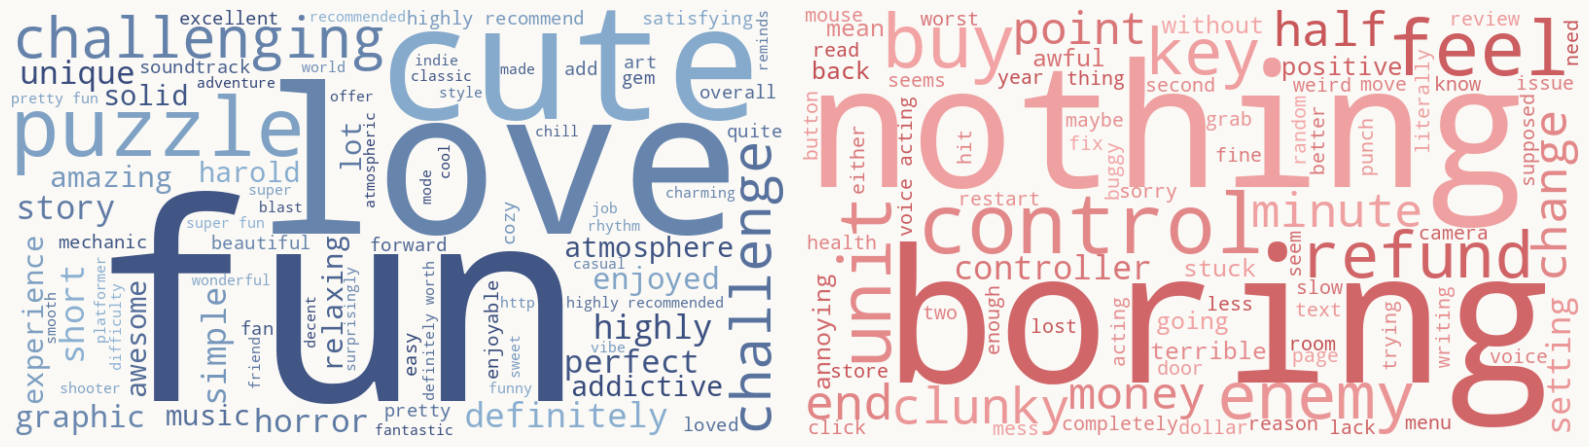

In [34]:
from wordcloud import WordCloud

# 차별 점수 기준 워드 가중치 산출
# - 긍정 클라우드: 긍정에서 두드러진 단어 (diff > 0), 가중치 = diff
# - 부정 클라우드: 부정에서 두드러진 단어 (diff < 0), 가중치 = abs(diff)
pos_freq = diff_df[diff_df['diff'] > 0].set_index('keyword')['diff'].nlargest(80).to_dict()
neg_freq = diff_df[diff_df['diff'] < 0].set_index('keyword')['diff'].abs().nlargest(80).to_dict()

def make_colormap(hex_dark, hex_light):
    return mcolors.LinearSegmentedColormap.from_list('custom', [hex_light, hex_dark])

pos_cmap = make_colormap('#2D3E71', '#8EB4D4')
neg_cmap = make_colormap('#C44E52', '#F4A8A8')

WC_KWARGS = dict(
    background_color='#FAF9F6',
    width=800,
    height=440,
    max_words=80,
    prefer_horizontal=0.85,
    collocations=False,
)

wc_pos = WordCloud(colormap=pos_cmap, **WC_KWARGS).generate_from_frequencies(pos_freq)
wc_neg = WordCloud(colormap=neg_cmap, **WC_KWARGS).generate_from_frequencies(neg_freq)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#FAF9F6')

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
# axes[0].set_title(
#     f'긍정 리뷰 특징 키워드  (n={len(pos):,})',
#     fontsize=14, fontweight='bold', color='#2D3E71', pad=12,
# )

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
# axes[1].set_title(
#     f'부정 리뷰 특징 키워드  (n={len(neg):,})',
#     fontsize=14, fontweight='bold', color='#C44E52', pad=12,
# )

# plt.suptitle(
#     '첫 반응군 리뷰 — 긍정 vs 부정 차별 키워드 워드 클라우드\n'
#     '(단어 크기 = 해당 그룹에서의 차별적 TF-IDF 점수)',
#     fontsize=12, color='#6B7280', y=1.02,
# )
plt.tight_layout()
plt.show()